<a href="https://colab.research.google.com/github/adrianestebanrodriguez/Repositorio_Datasets/blob/main/predictorvulnerabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, mean_squared_error

# Set seed para reproducibilidad
np.random.seed(42)
N = 8000

# ==========================================
# 1. GENERACIÓN DEL DATASET SINTÉTICO (8,000 REGISTROS)
# ==========================================

# Proporciones exactas
n_gestantes = int(N * 0.05)       # 400 (5%)
n_ninos = int(N * 0.08)           # 640 (8%)
n_jovenes_15_18 = int(N * 0.07)   # 560 (7%)
n_jovenes_18_30 = int(N * 0.20)   # 1600 (20%)
n_adultos_30_55 = int(N * 0.30)   # 2400 (30%)
n_mayores_55 = int(N * 0.30)      # 2400 (30%)

records = []

# Departamentos con zonas afectadas en Colombia
deptos = ['Chocó', 'Valle', 'Risaralda','Caldas', 'Quindío','Cauca','Antioquia']
pob_etnica = ['Afrocolombiano', 'Indígena', 'Mestizo/Blanco', 'Rrom']

def resolver_perfil(grupo_etario, min_edad, max_edad, pct_f, pct_m, pct_disc, es_gestante=False):
    registros_grupo = []

    if es_gestante:
        count = n_gestantes
    else:
        counts = {
            'Ninos': n_ninos,
            'Jovenes_15_18': n_jovenes_15_18,
            'Jovenes_18_30': n_jovenes_18_30,
            'Adultos_30_55': n_adultos_30_55,
            'Mayores_55': n_mayores_55
        }
        count = counts[grupo_etario]

    num_f = int(count * pct_f)
    num_m = count - num_f

    sexos = ['Femenino'] * num_f + ['Masculino'] * num_m
    np.random.shuffle(sexos)

    num_disc = int(count * pct_disc)
    discapacidad = [1] * num_disc + [0] * (count - num_disc)
    np.random.shuffle(discapacidad)

    for i in range(count):
        edad = int(np.random.randint(min_edad, max_edad + 1))
        sexo = sexos[i]
        disc = discapacidad[i]
        gestante = 1 if (es_gestante or (sexo == 'Femenino' and 15 <= edad <= 45 and np.random.rand() < 0.02)) else 0

        # Generación de variables socioeconómicas y mínimas OIT
        etnia = np.random.choice(pob_etnica, p=[0.2, 0.15, 0.63, 0.02])
        depto = np.random.choice(deptos)
        cabeza_hogar = 1 if (sexo == 'Femenino' and edad >= 18 and np.random.rand() < 0.45) else (1 if np.random.rand() < 0.2 else 0)

        # Empleo y Mínimos Vitales
        if edad < 18:
            tipo_empleo = 'No_Aplica'
            generando_ingresos = 0
        else:
            tipo_empleo = np.random.choice(['Informal', 'Cuenta_Propia', 'Formal_OIT', 'Desempleado'], p=[0.55, 0.20, 0.10, 0.15])
            generando_ingresos = 1 if tipo_empleo in ['Informal', 'Cuenta_Propia', 'Formal_OIT'] else 0

        salud_ok = np.random.choice([0, 1], p=[0.6, 0.4])
        alimentacion_ok = np.random.choice([0, 1], p=[0.55, 0.45])
        vivienda_ok = np.random.choice([0, 1], p=[0.7, 0.3])
        trabajo_formal_oit = 1 if tipo_empleo == 'Formal_OIT' else 0

        # Asignación de Ayuda Recibida
        ayuda_recibida = np.random.choice(
            ['Ninguna', 'Subsidio_Monetario', 'Kit_Alimentario_Salud', 'Vivienda_Temporal', 'Capacitacion_Emprendimiento'],
            p=[0.25, 0.30, 0.20, 0.15, 0.10]
        )

        # Cálculo sintético del Índice de Vulnerabilidad Inicial (0-100)
        vuln_base = 50.0
        vuln_base += (20 if salud_ok == 0 else -10)
        vuln_base += (20 if alimentacion_ok == 0 else -10)
        vuln_base += (20 if vivienda_ok == 0 else -10)
        vuln_base += (15 if trabajo_formal_oit == 0 else -15)
        vuln_base += (10 if gestante == 1 else 0)
        vuln_base += (10 if disc == 1 else 0)
        vuln_base += (10 if cabeza_hogar == 1 else 0)
        vuln_base += (10 if edad > 60 else 0)
        vuln_base = min(max(vuln_base + np.random.normal(0, 5), 0), 100)

        # Efecto sintético de la ayuda recibida
        efecto = 0
        if ayuda_recibida == 'Subsidio_Monetario':
            efecto = np.random.normal(15, 3)
        elif ayuda_recibida == 'Kit_Alimentario_Salud':
            efecto = np.random.normal(12, 2)
        elif ayuda_recibida == 'Vivienda_Temporal':
            efecto = np.random.normal(18, 4)
        elif ayuda_recibida == 'Capacitacion_Emprendimiento' and edad >= 18 and disc == 0:
            efecto = np.random.normal(25, 5)
        elif ayuda_recibida == 'Ninguna':
            efecto = 0

        vuln_post = min(max(vuln_base - efecto, 0), 100)

        # Clasificación de Necesidad de Oferta Especializada
        if gestante == 1 or (sexo == 'Femenino' and cabeza_hogar == 1 and edad < 30):
            oferta_target = 'Atencion_Materno_Infantil_y_Cuidado'
        elif disc == 1 or edad >= 60:
            oferta_target = 'Asistencia_AdultoMayor_Discapacidad'
        elif tipo_empleo in ['Informal', 'Desempleado', 'Cuenta_Propia'] and 18 <= edad < 60:
            oferta_target = 'Capital_Semilla_y_Formalizacion'
        elif vivienda_ok == 0:
            oferta_target = 'Subsidio_Vivienda_Reconstruccion'
        else:
            oferta_target = 'Monitoreo_y_Acompanamiento_Basico'

        registros_grupo.append({
            'edad': edad,
            'sexo': sexo,
            'es_gestante': gestante,
            'tiene_discapacidad': disc,
            'grupo_etario': grupo_etario,
            'etnia': etnia,
            'departamento': depto,
            'cabeza_de_hogar': cabeza_hogar,
            'generando_ingresos': generando_ingresos,
            'tipo_empleo': tipo_empleo,
            'salud_garantizada': salud_ok,
            'alimentacion_garantizada': alimentacion_ok,
            'vivienda_garantizada': vivienda_ok,
            'trabajo_formal_oit': trabajo_formal_oit,
            'ayuda_recibida': ayuda_recibida,
            'vulnerabilidad_pre': round(vuln_base, 2),
            'vulnerabilidad_post': round(vuln_post, 2),
            'efecto_ayuda': round(efecto, 2),
            'oferta_especializada_requerida': oferta_target
        })
    return registros_grupo

# Generar datos según reglas
data = []
data.extend(resolver_perfil('Gestantes', 15, 42, 1.0, 0.0, 0.05, es_gestante=True))
data.extend(resolver_perfil('Ninos', 1, 15, 0.50, 0.50, 0.05))
data.extend(resolver_perfil('Jovenes_15_18', 15, 18, 0.50, 0.50, 0.12))
data.extend(resolver_perfil('Jovenes_18_30', 18, 30, 0.50, 0.50, 0.12))
data.extend(resolver_perfil('Adultos_30_55', 30, 55, 0.50, 0.50, 0.25))
data.extend(resolver_perfil('Mayores_55', 55, 85, 0.60, 0.40, 0.40))

df = pd.DataFrame(data)

print(f"Dataset generado exitosamente con {len(df)} registros.")
print("\nDistribución por Grupos Etarios:")
print(df['grupo_etario'].value_counts(normalize=True) * 100)

# ==========================================
# 2. ENTRENAMIENTO DEL MODELO DE MACHINE LEARNING
# ==========================================

# Variables explicativas
cat_cols = ['sexo', 'etnia', 'departamento', 'tipo_empleo', 'ayuda_recibida']
num_cols = ['edad', 'es_gestante', 'tiene_discapacidad', 'cabeza_de_hogar', 'generando_ingresos',
            'salud_garantizada', 'alimentacion_garantizada', 'vivienda_garantizada', 'trabajo_formal_oit']

X = df[cat_cols + num_cols]
y_riesgo = df['vulnerabilidad_post']
y_oferta = df['oferta_especializada_requerida']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Pipeline 1: Regresor del nivel de vulnerabilidad post-ayuda
model_vuln = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Pipeline 2: Clasificador de Oferta Especializada Requerida
model_oferta = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

X_train, X_test, y_vuln_train, y_vuln_test, y_ofe_train, y_ofe_test = train_test_split(
    X, y_riesgo, y_oferta, test_size=0.2, random_state=42
)

model_vuln.fit(X_train, y_vuln_train)
model_oferta.fit(X_train, y_ofe_train)

print("\n--- Evaluación del Modelo de Vulnerabilidad (RMSE) ---")
preds_vuln = model_vuln.predict(X_test)
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_vuln_test, preds_vuln)):.2f} puntos")

print("\n--- Evaluación del Modelo de Oferta Especializada ---")
preds_ofe = model_oferta.predict(X_test)
print(classification_report(y_ofe_test, preds_ofe))

# ==========================================
# 3. FUNCIÓN DE INFERENCIA PARA NUEVOS DAMNIFICADOS
# ==========================================

def evaluar_persona_damnificada(perfil_dict):
    """
    Recibe un diccionario con las particularidades de una persona y calcula:
    1. Score de Vulnerabilidad Estimado.
    2. Clasificación de Riesgo.
    3. Tipo de Ayuda Especializada Recomendada.
    """
    input_df = pd.DataFrame([perfil_dict])
    score_vuln = model_vuln.predict(input_df)[0]
    oferta_rec = model_oferta.predict(input_df)[0]

    if score_vuln >= 70:
        nivel_riesgo = "CRÍTICO"
    elif score_vuln >= 45:
        nivel_riesgo = "ALTO"
    elif score_vuln >= 25:
        nivel_riesgo = "MEDIO"
    else:
        nivel_riesgo = "BAJO"

    return {
        'Score_Vulnerabilidad_Estimado': round(score_vuln, 2),
        'Nivel_Riesgo': nivel_riesgo,
        'Oferta_Especializada_Recomendada': oferta_rec
    }

# Ejemplo de prueba con una persona nueva
persona_ejemplo = {
    'edad': 28,
    'sexo': 'Femenino',
    'es_gestante': 1,
    'tiene_discapacidad': 0,
    'etnia': 'Afrocolombiano',
    'departamento': 'Cauca',
    'cabeza_de_hogar': 1,
    'generando_ingresos': 0,
    'tipo_empleo': 'Desempleado',
    'salud_garantizada': 0,
    'alimentacion_garantizada': 0,
    'vivienda_garantizada': 0,
    'trabajo_formal_oit': 0,
    'ayuda_recibida': 'Ninguna'
}

resultado = evaluar_persona_damnificada(persona_ejemplo)
print("\n--- EVALUACIÓN DE PERFIL INDIVIDUAL ---")
for k, v in resultado.items():
    print(f"{k}: {v}")

Dataset generado exitosamente con 8000 registros.

Distribución por Grupos Etarios:
grupo_etario
Adultos_30_55    30.0
Mayores_55       30.0
Jovenes_18_30    20.0
Ninos             8.0
Jovenes_15_18     7.0
Gestantes         5.0
Name: proportion, dtype: float64

--- Evaluación del Modelo de Vulnerabilidad (RMSE) ---
Root Mean Squared Error: 5.50 puntos

--- Evaluación del Modelo de Oferta Especializada ---
                                     precision    recall  f1-score   support

Asistencia_AdultoMayor_Discapacidad       1.00      1.00      1.00       591
Atencion_Materno_Infantil_y_Cuidado       1.00      0.99      0.99       194
    Capital_Semilla_y_Formalizacion       1.00      1.00      1.00       572
  Monitoreo_y_Acompanamiento_Basico       1.00      1.00      1.00        67
   Subsidio_Vivienda_Reconstruccion       0.99      1.00      1.00       176

                           accuracy                           1.00      1600
                          macro avg       1.00   

In [13]:
# Re-entrenamiento con la nueva lista de departamentos
# Esto asegura que el preprocesador reconozca 'Valle', 'Risaralda', 'Caldas', etc.

X = df[cat_cols + num_cols]
y_riesgo = df['vulnerabilidad_post']
y_oferta = df['oferta_especializada_requerida']

X_train, X_test, y_vuln_train, y_vuln_test, y_ofe_train, y_ofe_test = train_test_split(
    X, y_riesgo, y_oferta, test_size=0.2, random_state=42
)

# Ajustar modelos nuevamente
model_vuln.fit(X_train, y_vuln_train)
model_oferta.fit(X_train, y_ofe_train)

# Exportar los nuevos archivos .pkl
joblib.dump(model_vuln, 'modelo_vulnerabilidad.pkl')
joblib.dump(model_oferta, 'modelo_oferta.pkl')

print("Modelos actualizados y exportados exitosamente con los nuevos departamentos.")

Modelos actualizados y exportados exitosamente con los nuevos departamentos.


In [15]:
from sklearn.metrics import accuracy_score, r2_score

# Cálculo de métricas de confianza
confianza_oferta = accuracy_score(y_ofe_test, model_oferta.predict(X_test))
confianza_vulnerabilidad = r2_score(y_vuln_test, model_vuln.predict(X_test))

print(f"--- MÉTRICAS DE CONFIANZA DEL SISTEMA ---")
print(f"1. Confianza en Recomendación de Oferta (Accuracy): {confianza_oferta * 100:.2f}%")
print(f"2. Calidad del Score de Vulnerabilidad (R² Score): {confianza_vulnerabilidad:.4f}")

if confianza_oferta > 0.95:
    print("\nEl modelo de clasificación es altamente confiable para los datos actuales.")

--- MÉTRICAS DE CONFIANZA DEL SISTEMA ---
1. Confianza en Recomendación de Oferta (Accuracy): 99.88%
2. Calidad del Score de Vulnerabilidad (R² Score): 0.9239

El modelo de clasificación es altamente confiable para los datos actuales.


In [16]:
import sklearn
print(f"La versión de scikit-learn utilizada es: {sklearn.__version__}")

La versión de scikit-learn utilizada es: 1.6.1


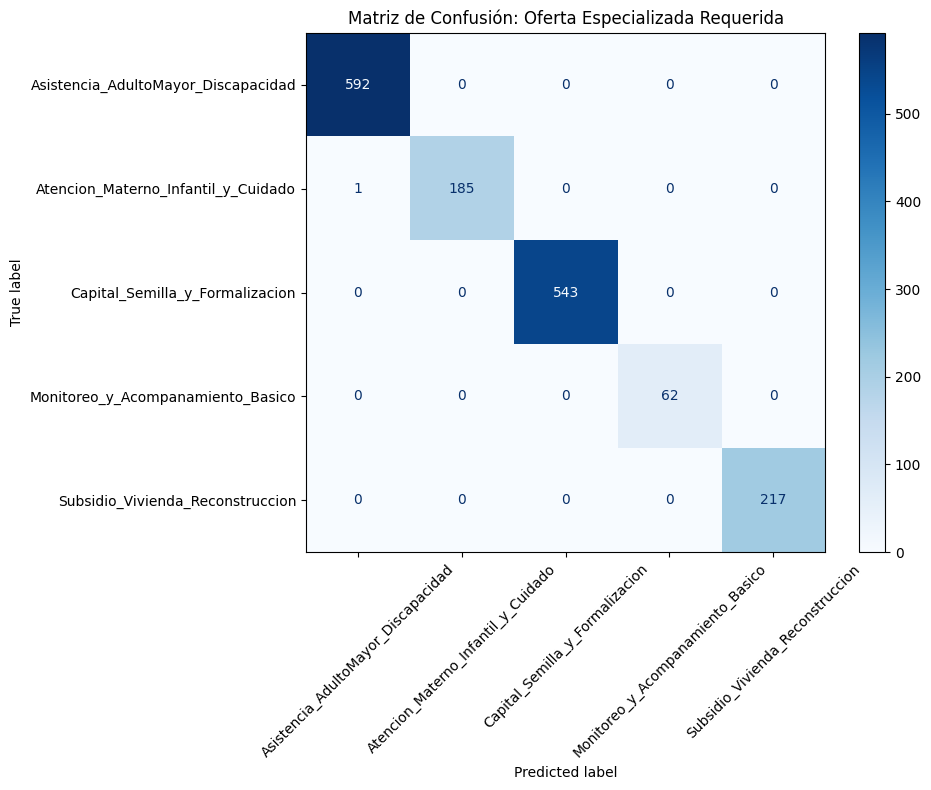

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generar las predicciones para el set de prueba
# (Nota: preds_ofe ya existe en el estado del kernel, pero lo recalculamos para claridad)
preds_ofe = model_oferta.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_ofe_test, preds_ofe)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_oferta.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Matriz de Confusión: Oferta Especializada Requerida')
plt.tight_layout()
plt.show()

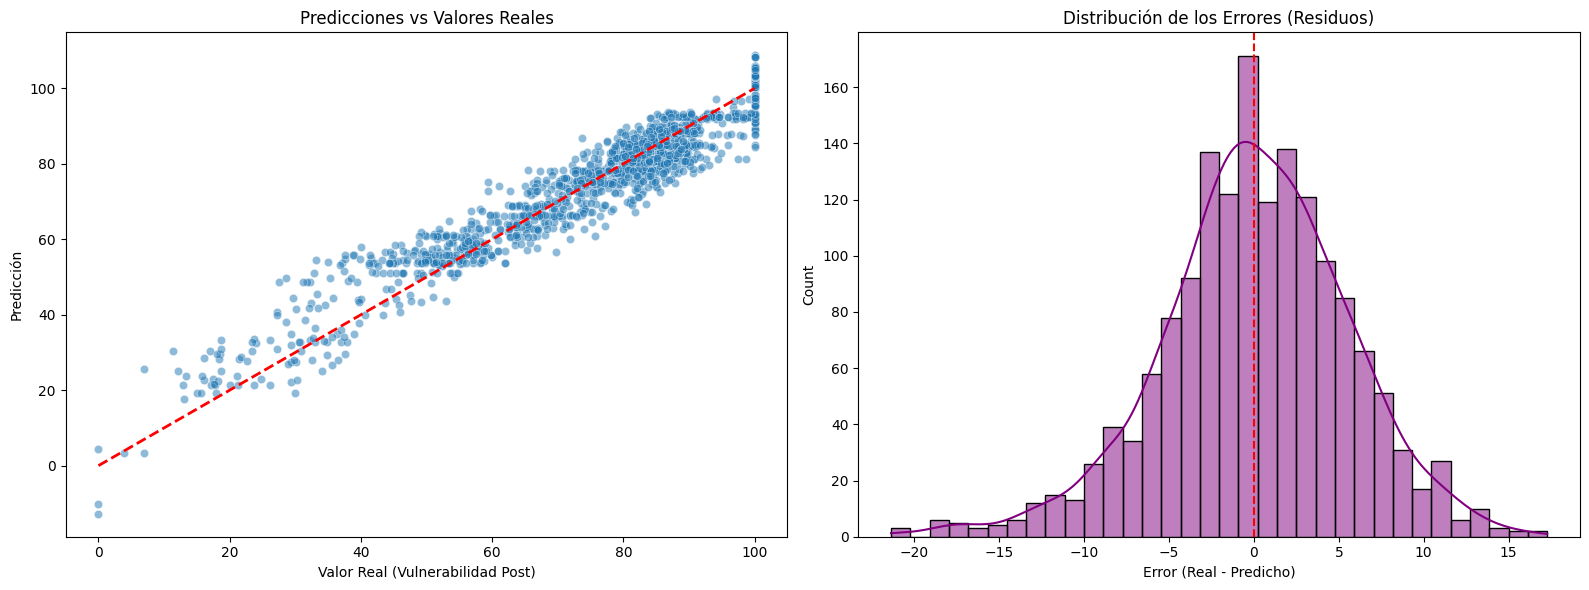

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular residuos
residuos = y_vuln_test - preds_vuln

# Configurar la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Predicciones vs Valores Reales
sns.scatterplot(x=y_vuln_test, y=preds_vuln, ax=ax1, alpha=0.5)
ax1.plot([y_vuln_test.min(), y_vuln_test.max()], [y_vuln_test.min(), y_vuln_test.max()], 'r--', lw=2)
ax1.set_title('Predicciones vs Valores Reales')
ax1.set_xlabel('Valor Real (Vulnerabilidad Post)')
ax1.set_ylabel('Predicción')

# Gráfico 2: Distribución de Residuos
sns.histplot(residuos, kde=True, ax=ax2, color='purple')
ax2.axvline(x=0, color='red', linestyle='--')
ax2.set_title('Distribución de los Errores (Residuos)')
ax2.set_xlabel('Error (Real - Predicho)')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

# Definir un nuevo perfil de prueba
persona_prueba_2 = {
    'edad': 72,
    'sexo': 'Masculino',
    'es_gestante': 0,
    'tiene_discapacidad': 1,
    'etnia': 'Indígena',
    'departamento': 'Nariño',
    'cabeza_de_hogar': 0,
    'generando_ingresos': 0,
    'tipo_empleo': 'Desempleado',
    'salud_garantizada': 0,
    'alimentacion_garantizada': 0,
    'vivienda_garantizada': 0,
    'trabajo_formal_oit': 0,
    'ayuda_recibida': 'Ninguna'
}

# Ejecutar la evaluación
resultado_2 = evaluar_persona_damnificada(persona_prueba_2)

print("--- EVALUACIÓN DE NUEVO PERFIL (ADULTO MAYOR CON DISCAPACIDAD) ---")
for k, v in resultado_2.items():
    print(f"{k}: {v}")

--- EVALUACIÓN DE NUEVO PERFIL (ADULTO MAYOR CON DISCAPACIDAD) ---
Score_Vulnerabilidad_Estimado: 104.95
Nivel_Riesgo: CRÍTICO
Oferta_Especializada_Recomendada: Asistencia_AdultoMayor_Discapacidad


### Ejemplo de Aplicación Web con Streamlit

Para ejecutar esto localmente, necesitarías instalar streamlit (`pip install streamlit`). Este código crea un formulario lateral para ingresar datos y muestra el diagnóstico en el panel central.

In [9]:
import joblib

# 1. Guardar los modelos para usarlos fuera de este notebook
joblib.dump(model_vuln, 'modelo_vulnerabilidad.pkl')
joblib.dump(model_oferta, 'modelo_oferta.pkl')

# 2. Estructura básica de una app en Streamlit (Pseudo-código explicativo)
app_code = """
import streamlit as st
import pandas as pd
import joblib

# Cargar modelos
mod_v = joblib.load('modelo_vulnerabilidad.pkl')
mod_o = joblib.load('modelo_oferta.pkl')

st.title("Sistema de Priorización de Damnificados")

with st.sidebar:
    st.header("Datos del Damnificado")
    edad = st.number_input("Edad", 0, 100, 25)
    sexo = st.selectbox("Sexo", ["Femenino", "Masculino"])
    depto = st.selectbox("Departamento", ['Quindío', 'Cauca', 'Nariño', 'Antioquia', 'Cundinamarca', 'Chocó'])
    # ... otros campos ...

if st.button("Calcular Prioridad"):
    # Crear DataFrame con el input
    input_data = pd.DataFrame([{ 'edad': edad, 'sexo': sexo, ... }])

    score = mod_v.predict(input_data)[0]
    oferta = mod_o.predict(input_data)[0]

    st.metric("Puntaje de Vulnerabilidad", f"{score:.2f}")
    st.success(f"Acción Recomendada: {oferta}")
"""

print("Modelos guardados como .pkl. Ya puedes descargarlos desde la pestaña de archivos a la izquierda.")

Modelos guardados como .pkl. Ya puedes descargarlos desde la pestaña de archivos a la izquierda.


### Código Completo para `app.py` (Streamlit)

Copia este bloque en un archivo llamado `app.py` en tu entorno local para ejecutar la aplicación. Asegúrate de tener los archivos `.pkl` en la misma carpeta.

In [14]:
!pip install -q streamlit
import streamlit as st
import pandas as pd
import joblib

# Configuración de página
st.set_page_config(page_title="Priorización de Ayudas", layout="wide")

# Carga de modelos
try:
    mod_v = joblib.load('modelo_vulnerabilidad.pkl')
    mod_o = joblib.load('modelo_oferta.pkl')
except:
    st.error("Error: No se encontraron los archivos .pkl. Asegúrate de descargarlos del notebook.")

st.title("📋 Sistema de Clasificación y Riesgo para Damnificados")

with st.sidebar:
    st.header("Perfil del Damnificado")

    # Variables Categóricas
    sexo = st.selectbox("Sexo", ["Femenino", "Masculino"])
    etnia = st.selectbox("Etnia", ['Afrocolombiano', 'Indígena', 'Mestizo/Blanco', 'Rrom'])
    # Lista actualizada de departamentos
    depto = st.selectbox("Departamento", ['Chocó', 'Valle', 'Risaralda', 'Caldas', 'Quindío', 'Cauca', 'Antioquia'])
    empleo = st.selectbox("Tipo de Empleo", ['Informal', 'Cuenta_Propia', 'Formal_OIT', 'Desempleado', 'No_Aplica'])
    ayuda = st.selectbox("Ayuda Recibida Previamente", ['Ninguna', 'Subsidio_Monetario', 'Kit_Alimentario_Salud', 'Vivienda_Temporal', 'Capacitacion_Emprendimiento'])

    # Variables Numéricas/Binarias
    edad = st.slider("Edad", 0, 100, 30)
    gestante = st.checkbox("¿Es gestante?")
    discapacidad = st.checkbox("¿Tiene discapacidad?")
    cabeza_hogar = st.checkbox("¿Es cabeza de hogar?")
    ingresos = st.checkbox("¿Genera ingresos actualmente?")
    salud = st.checkbox("¿Tiene acceso a salud?")
    alimento = st.checkbox("¿Tiene alimentación garantizada?")
    vivienda = st.checkbox("¿Tiene vivienda segura?")
    formal = st.checkbox("¿Tiene trabajo formal (OIT)?")

if st.button("Generar Diagnóstico"):
    # 1. Mapeo exacto de las columnas del modelo
    input_dict = {
        'sexo': sexo,
        'etnia': etnia,
        'departamento': depto,
        'tipo_empleo': empleo,
        'ayuda_recibida': ayuda,
        'edad': edad,
        'es_gestante': 1 if gestante else 0,
        'tiene_discapacidad': 1 if discapacidad else 0,
        'cabeza_de_hogar': 1 if cabeza_hogar else 0,
        'generando_ingresos': 1 if ingresos else 0,
        'salud_garantizada': 1 if salud else 0,
        'alimentacion_garantizada': 1 if alimento else 0,
        'vivienda_garantizada': 1 if vivienda else 0,
        'trabajo_formal_oit': 1 if formal else 0
    }

    df_input = pd.DataFrame([input_dict])

    # 2. Predicciones
    score = mod_v.predict(df_input)[0]
    oferta = mod_o.predict(df_input)[0]

    # 3. Mostrar Resultados
    col1, col2 = st.columns(2)

    with col1:
        st.metric("Índice de Vulnerabilidad Estimado", f"{score:.2f}%")
        if score >= 70: st.error("Nivel de Riesgo: CRÍTICO")
        elif score >= 45: st.warning("Nivel de Riesgo: ALTO")
        else: st.success("Nivel de Riesgo: CONTROLADO")

    with col2:
        st.subheader("Oferta Recomendada")
        st.info(f"📍 {oferta}")

2026-08-22 22:06:53.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 22:06:53.390 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 22:06:53.391 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 22:06:53.400 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 22:06:53.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 22:06:53.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 22:06:53.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 22:06:53.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar